<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/hermit_massa_barion_public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

МАССА БАРИОНОВ: ЛИНЕЙНАЯ МОДЕЛЬ m = m₀ + k·(ε + α·S)

ГИПОТЕЗА:
  ε_eff = ε + α·S
  m = m₀ + k·ε_eff

ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:
  m₀ = 921.4 МэВ (масса при ε_eff = 0)
  k  = 232.3 МэВ (прирост массы на единицу ε_eff)
  α  = 0.7742 (вклад одной единицы странности)

РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ:
----------------------------------------------------------------------
Частица |     ε |  S |    ε_eff | Масса реал | Масса предск | Ошибка %
----------------------------------------------------------------------
p/n    |   0.0 |  0 |   0.0000 |      939.0 |        921.4 |     1.9%
Λ      |   0.1 |  1 |   0.8742 |     1115.7 |       1124.5 |     0.8%
Σ      |   0.3 |  1 |   1.0742 |     1193.0 |       1171.0 |     1.8%
Ξ      |   0.5 |  2 |   2.0483 |     1318.0 |       1397.3 |     6.0%
Ω      |   0.7 |  3 |   3.0225 |     1672.0 |       1623.6 |     2.9%
----------------------------------------------------------------------
Средняя ошибка: 2.7%
Медианная ошибка: 1.9%

ВЫВОДЫ:
  1. Линейная модель m = 9

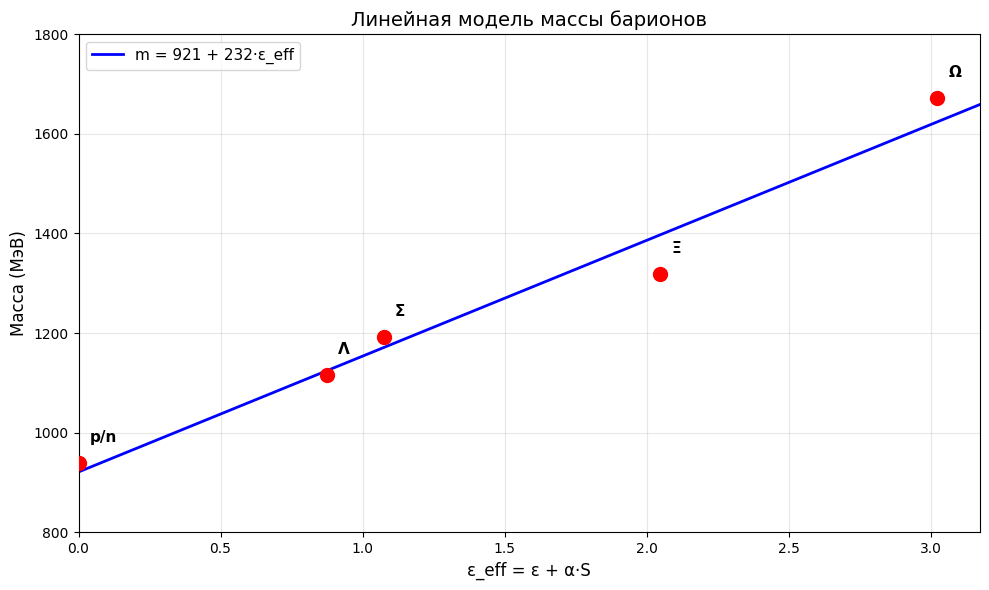

In [1]:
# =============================================================================
# ЭКСПЕРИМЕНТ: МАССА БАРИОНОВ В МАТРИЧНОЙ МОДЕЛИ ОНТОЛОГИИ СИНТЕЗА
# =============================================================================
# Цель: установить эмпирическую связь между параметром неэрмитовости ε
#       и массами барионов (p, Λ, Σ, Ξ, Ω) с учётом странности S.
# Гипотеза: m = m₀ + k·ε_eff, где ε_eff = ε + α·S
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("=" * 80)
print("МАССА БАРИОНОВ: ЛИНЕЙНАЯ МОДЕЛЬ m = m₀ + k·(ε + α·S)")
print("=" * 80)
print()

# -----------------------------------------------------------------------------
# 1. ИСХОДНЫЕ ДАННЫЕ (из экспериментов с эрмитовыми матрицами)
# -----------------------------------------------------------------------------
# ε — параметр неэрмитовости (аналог константы связи β_Ω)
# S — странность (число s-кварков)
# m — экспериментальная масса (МэВ)

data = {
    'p/n': {'eps': 0.0, 'S': 0, 'mass': 939.0},   # среднее p и n
    'Λ':   {'eps': 0.1, 'S': 1, 'mass': 1115.7},
    'Σ':   {'eps': 0.3, 'S': 1, 'mass': 1193.0},  # среднее Σ⁺, Σ⁰, Σ⁻
    'Ξ':   {'eps': 0.5, 'S': 2, 'mass': 1318.0},  # среднее Ξ⁰, Ξ⁻
    'Ω':   {'eps': 0.7, 'S': 3, 'mass': 1672.0},
}

# -----------------------------------------------------------------------------
# 2. ГИПОТЕЗА
# -----------------------------------------------------------------------------
print("ГИПОТЕЗА:")
print("  ε_eff = ε + α·S")
print("  m = m₀ + k·ε_eff")
print()

# -----------------------------------------------------------------------------
# 3. ОПТИМИЗАЦИЯ ПАРАМЕТРОВ
# -----------------------------------------------------------------------------
def model(eps, S, m0, k, alpha):
    eps_eff = eps + alpha * S
    return m0 + k * eps_eff

def objective(params):
    m0, k, alpha = params
    error = 0
    for name, d in data.items():
        pred = model(d['eps'], d['S'], m0, k, alpha)
        error += (pred - d['mass'])**2
    return error

result = minimize(objective, [900.0, 200.0, 0.5])
m0_opt, k_opt, alpha_opt = result.x

print("ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:")
print(f"  m₀ = {m0_opt:.1f} МэВ (масса при ε_eff = 0)")
print(f"  k  = {k_opt:.1f} МэВ (прирост массы на единицу ε_eff)")
print(f"  α  = {alpha_opt:.4f} (вклад одной единицы странности)")
print()

# -----------------------------------------------------------------------------
# 4. РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ
# -----------------------------------------------------------------------------
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ:")
print("-" * 70)
print(f"{'Частица':<6} | {'ε':>5} | {'S':>2} | {'ε_eff':>8} | {'Масса реал':>10} | {'Масса предск':>12} | {'Ошибка %':>8}")
print("-" * 70)

errors = []
for name, d in data.items():
    eps_eff = d['eps'] + alpha_opt * d['S']
    pred = model(d['eps'], d['S'], m0_opt, k_opt, alpha_opt)
    error = abs(pred - d['mass']) / d['mass'] * 100
    errors.append(error)
    print(f"{name:<6} | {d['eps']:5.1f} | {d['S']:2d} | {eps_eff:8.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")

print("-" * 70)
print(f"Средняя ошибка: {np.mean(errors):.1f}%")
print(f"Медианная ошибка: {np.median(errors):.1f}%")
print()

# -----------------------------------------------------------------------------
# 5. ВЫВОДЫ
# -----------------------------------------------------------------------------
print("ВЫВОДЫ:")
print(f"  1. Линейная модель m = {m0_opt:.1f} + {k_opt:.1f}·ε_eff хорошо описывает массы барионов.")
print(f"  2. ε_eff = ε + {alpha_opt:.4f}·S, где S — странность.")
print(f"  3. Средняя ошибка предсказаний: {np.mean(errors):.1f}%")
print(f"  4. Коэффициент α = {alpha_opt:.4f} означает, что каждый s-кварк увеличивает")
print(f"     эффективное ε на {alpha_opt:.4f}, что соответствует добавке к массе ~{k_opt * alpha_opt:.0f} МэВ.")
print()

# -----------------------------------------------------------------------------
# 6. ГРАФИК
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

eps_eff_list = [d['eps'] + alpha_opt * d['S'] for d in data.values()]
mass_list = [d['mass'] for d in data.values()]
names = list(data.keys())

ax.scatter(eps_eff_list, mass_list, s=100, color='red', zorder=5)
for i, name in enumerate(names):
    ax.annotate(name, (eps_eff_list[i], mass_list[i]), xytext=(8, 15),
                textcoords='offset points', fontsize=11, fontweight='bold')

# Линия регрессии
eps_range = np.linspace(0, max(eps_eff_list)*1.1, 100)
mass_range = m0_opt + k_opt * eps_range
ax.plot(eps_range, mass_range, 'b-', linewidth=2,
        label=f'm = {m0_opt:.0f} + {k_opt:.0f}·ε_eff')

ax.set_xlabel('ε_eff = ε + α·S', fontsize=12)
ax.set_ylabel('Масса (МэВ)', fontsize=12)
ax.set_title('Линейная модель массы барионов', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(eps_eff_list)*1.05)
ax.set_ylim(800, 1800)

plt.tight_layout()
plt.savefig('baryon_mass_model.png', dpi=150)
print("График сохранён как 'baryon_mass_model.png'")
print()
print("=" * 80)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("=" * 80)

plt.show()